# 1.Package Import

In [ ]:
from bmovie_code import gen_table1_subj_info
from pynwb import NWBHDF5IO
from pathlib import Path
import numpy as np
import pandas as pd

from new_code import data_summary, load_data_into_pds, load_data_into_dict, slicer, label, feature, utils

import pickle

In [2]:
%load_ext autoreload
%autoreload 2

# 2. Global file location (need to specify your own path)

In [3]:
NWB_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files"
BIDS_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/bids_files"

In [4]:
gen_table1_subj_info.main(
    nwb_input_dir=NWB_DIR,
    bids_datadir=BIDS_DIR
)

In [5]:
# nwb_df, bids_df = data_summary.run_summary(NWB_DIR, BIDS_DIR, max_nwb_files=3, max_bids_files_each=5)

# nwb_df.head(), bids_df.head()

# 3. Load labels and data

In [5]:
# labels
with open("../assets/annotations/short_faceannots.pkl", "rb") as f:
    face_annots = pickle.load(f)

type(face_annots)
# print(list(face_annots.items())[:10])

path = "../assets/annotations/scenecut_info.csv"
scenecut_info = pd.read_csv(path)

print(scenecut_info.head())

   scene_id  shot_start_fr  shot_start_t  shot_dur_t  location cut_type  \
0       1.0            1.0          0.00        4.72  backyard      cut   
1       1.0          119.0          4.72       10.28  backyard      cut   
2       1.0          376.0         15.00        1.72  backyard      cut   
3       1.0          419.0         16.72        2.36  backyard      cut   
4       1.0          478.0         19.08        2.64  backyard      cut   

   cut_dur_t  cut_dur_fr  
0        0.0           0  
1        0.0           0  
2        0.0           0  
3        0.0           0  
4        0.0           0  


In [6]:
df_face_note = label.build_face_feature_df(face_annots, target_id="Jacky")
print(df_face_note.tail())

        frame_key  frame_idx  movie_time  n_faces  total_face_area  \
9373  frame_11898      11898      475.92        2      35470.00073   
9374  frame_11899      11899      475.96        2      35470.00073   
9375  frame_11900      11900      476.00        2      35470.00073   
9376  frame_11901      11901      476.04        2      35470.00073   
9377  frame_11902      11902      476.08        2      35470.00073   

      max_face_area  Jacky_present  any_front_face dominant_emotion  \
9373   24058.686485              0               1        surprised   
9374   24058.686485              0               1        surprised   
9375   24058.686485              0               1        surprised   
9376   24058.686485              0               1        surprised   
9377   24058.686485              0               1        surprised   

      emo_afraid  emo_angry  emo_happy  emo_neutral  emo_surprised  
9373       False      False      False        False           True  
9374       Fal

## 3.1 Label Check

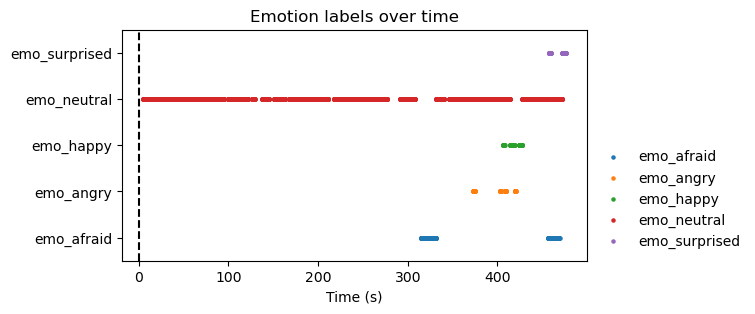

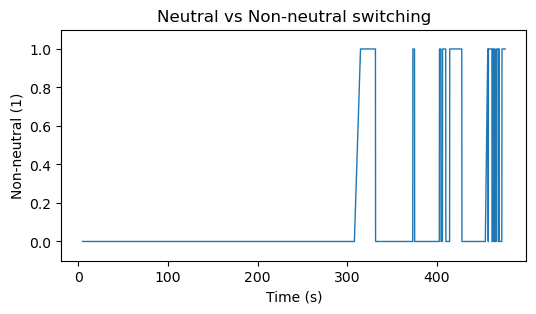

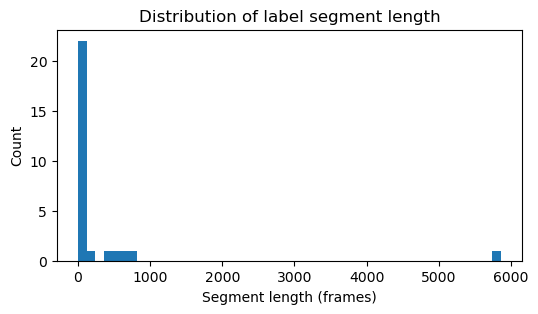

median: 47.0
short (<5 frames): 0.0


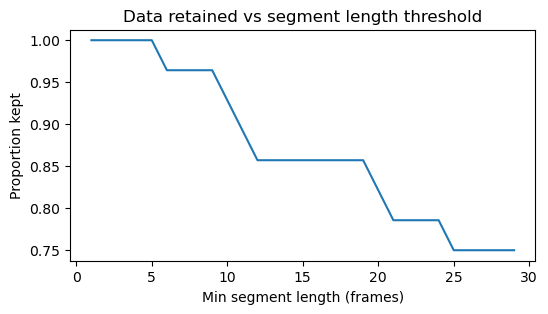

In [45]:
import matplotlib.pyplot as plt

emo_cols = [
    "emo_afraid",
    "emo_angry",
    "emo_happy",
    "emo_neutral",
    "emo_surprised"
]

t = df_face_note["movie_time"].values

# ===================================
# face emotion label check
# ===================================
plt.figure(figsize=(6, 3))

for i, col in enumerate(emo_cols):
    y = df_face_note[col].astype(int) * (i + 1)
    plt.scatter(t, y, s=5, label=col)

plt.axvline(0, color="black", linestyle="--")
plt.yticks(range(1, len(emo_cols)+1), emo_cols)
plt.ylim(0.5, len(emo_cols)+0.5)
plt.xlabel("Time (s)")
plt.title("Emotion labels over time")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.show()

# ===================================
# face emotion switching
# ===================================
is_non_neutral = ~df_face_note["emo_neutral"]

plt.figure(figsize=(6, 3))
plt.plot(t, is_non_neutral.astype(int), linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Non-neutral (1)")
plt.title("Neutral vs Non-neutral switching")
plt.ylim(-0.1, 1.1)
plt.show()

# ===================================
# distribution check
# ===================================
labels = df_face_note["dominant_emotion"].values

segments = []
start = 0

for i in range(1, len(labels)):
    if labels[i] != labels[i-1]:
        segments.append((labels[i-1], start, i-1))
        start = i

segments.append((labels[-1], start, len(labels)-1))

lengths = [end - start + 1 for (_, start, end) in segments]

plt.figure(figsize=(6, 3))
plt.hist(lengths, bins=50)
plt.xlabel("Segment length (frames)")
plt.ylabel("Count")
plt.title("Distribution of label segment length")
plt.show()

print("median:", np.median(lengths))
print("short (<5 frames):", np.mean(np.array(lengths) < 5))

# ===================================
# screen check
# ===================================

lengths = np.array(lengths)

thresholds = np.arange(1, 30)
proportion = [(lengths >= th).mean() for th in thresholds]

plt.figure(figsize=(6, 3))
plt.plot(thresholds, proportion)
plt.xlabel("Min segment length (frames)")
plt.ylabel("Proportion kept")
plt.title("Data retained vs segment length threshold")
plt.show()

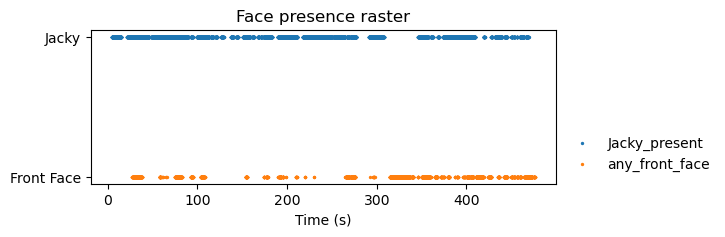

In [59]:
import matplotlib.pyplot as plt

t = df_face_note["movie_time"].values

jacky = df_face_note["Jacky_present"].astype(int).values
front = df_face_note["any_front_face"].astype(int).values

plt.figure(figsize=(6, 2))

plt.scatter(t[jacky == 1], [1]*np.sum(jacky==1), s=2, label="Jacky_present")
plt.scatter(t[front == 1], [0]*np.sum(front==1), s=2, label="any_front_face")

plt.yticks([0, 1], ["Front Face", "Jacky"])
plt.xlabel("Time (s)")
plt.title("Face presence raster")
plt.legend(bbox_to_anchor=(1.0,0), loc="lower left", frameon=False)
plt.show()

In [9]:
nwb_path = load_data_into_pds.find_nwb_file_for_subject(NWB_DIR, "CS41")
print("Using:", nwb_path)

io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
nwb = io.read()

print("\n=== acquisition keys ===")
print(list(nwb.acquisition.keys()))

print("\n=== processing modules ===")
print(list(nwb.processing.keys()))

for mod_name, mod in nwb.processing.items():
    print(f"\n--- processing[{mod_name}] keys ---")
    try:
        print(list(mod.data_interfaces.keys()))
    except Exception as e:
        print("cannot list data_interfaces:", e)

print("\n=== stimulus keys ===")
print(list(getattr(nwb, "stimulus", {}).keys()))

print("\n=== intervals ===")
print(list(getattr(nwb, "intervals", {}).keys()))

io.close()

Using: /Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb

=== acquisition keys ===
['events_ttl', 'experiment_ids']

=== processing modules ===
['behavior', 'ecephys']

--- processing[behavior] keys ---
['Blink', 'EyeTracking', 'Fixation', 'PupilTracking', 'Saccade']

--- processing[ecephys] keys ---
['LFP_macro', 'LFP_micro']

=== stimulus keys ===
['movieframe_time']

=== intervals ===
['trials']


In [10]:
from pynwb import NWBHDF5IO
io = NWBHDF5IO("/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb", "r", load_namespaces=True)
nwb = io.read()

ece = nwb.processing["ecephys"]
print("LFP_macro electrical_series keys:", list(ece["LFP_macro"].electrical_series.keys()))
print("LFP_micro electrical_series keys:", list(ece["LFP_micro"].electrical_series.keys()))

beh = nwb.processing["behavior"]
print("EyeTracking spatial_series keys:", list(beh["EyeTracking"].spatial_series.keys()))
print("PupilTracking time_series keys:", list(beh["PupilTracking"].time_series.keys()))

io.close()

LFP_macro electrical_series keys: ['ElectricalSeries']
LFP_micro electrical_series keys: ['ElectricalSeries']
EyeTracking spatial_series keys: ['SpatialSeries']
PupilTracking time_series keys: ['TimeSeries']


In [11]:
sub_nums = [41]

data = load_data_into_dict.load_multimodal_subjects_movie_aligned(
    sub_nums=[41],
    nwb_root=NWB_DIR,
    bids_root=BIDS_DIR,
    max_nwb_samples=2000000,
    grid_source= "lfp_raw",   # {"movie_frame_time", "uniform", "lfp_raw"}
    grid_dt = None,         # used when grid_source == "uniform"
    uniform_grid_include_baseline = True,

    compute_firing_rate= True,
    firing_rate_bin_width= None,  # if None, infer from t_grid
    compute_lfp_bandpower= True,
    lfp_bandpower_on_raw= True,       # recommended
    bands= None,

    # optional fmri
    load_fmri= False,
    fmri_max_runs= None,
)

print(data[41].keys())
print(data[41]['meta'])
print(data[41]["lfp_macro"].shape, data[41]["eye_gaze"].shape)
# print("n_units:", data[41]["meta"]["n_units"], "firing_rate:", data[41]["firing_rate"].shape)
print("band keys:", list(data[41]["lfp_bandpower"].keys()))
# data[41]["lfp_macro"][:, :5]
x = data[41]["lfp_macro"]
t = data[41]["time_grid"]
print(x.shape, len(t))

[sub 41] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb
[sub 41] fs_macro=1000.0, fs_micro=1000.0, fs_eye=499.9999999976126
[sub 41] t_macro_movie range=(-10.000, 753.963)
[sub 41] movieframe_time(frame) range=(0.000, 11970.000)
[sub 41] movieframe_time_sec range=(0.000, 478.800)
[sub 41] t_grid len=763964 source=lfp_raw
dict_keys(['spikes', 'firing_rate', 'lfp_macro', 'lfp_micro', 'lfp_bandpower', 'eye_gaze', 'pupil', 'time_grid', 'movieframe_time', 'movieframe_time_sec', 'time_raw', 'bold', 'meta'])
{'sub': 41, 'bids_sub': 'p41cs', 'nwb_sub': 'CS41', 'nwb_path': '/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb', 'fs_macro_raw': np.float64(1000.0), 'fs_micro_raw': np.float64(1000.0), 'fs_eye_raw': np.float64(499.9999999976126), 'movie_fps_nominal': 25.0, 'grid_source': 'lfp_raw', 'grid_dt': 0.000999999999990564, 'time_reference': 'movie_start_is_z

In [12]:
eye_data = data[41]["eye_gaze"]
print("movie_time shape:", data[41]["movieframe_time"].shape)
print("eye_gaze shape:", eye_data.shape)
print(eye_data[:5])

movie_time shape: (11971,)
eye_gaze shape: (763964, 2)
[[630. 548.]
 [630. 548.]
 [630. 548.]
 [630. 548.]
 [630. 548.]]


Text(0.5, 1.0, 'PCA Explained Variance')

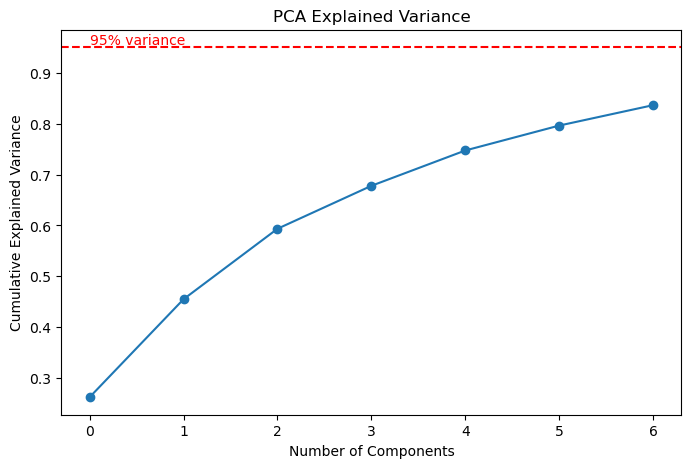

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

seg = slicer.slice_modalities_by_movie_time_sec(data[41], 0.0, 10.0)

X = seg["lfp_micro"]

X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(
    y=0.95,
    color='r',
    linestyle='--',
    label='95% variance'
)

plt.text(
    x=0,
    y=0.95,
    s="95% variance",
    color='r',
    ha='left',
    va='bottom'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

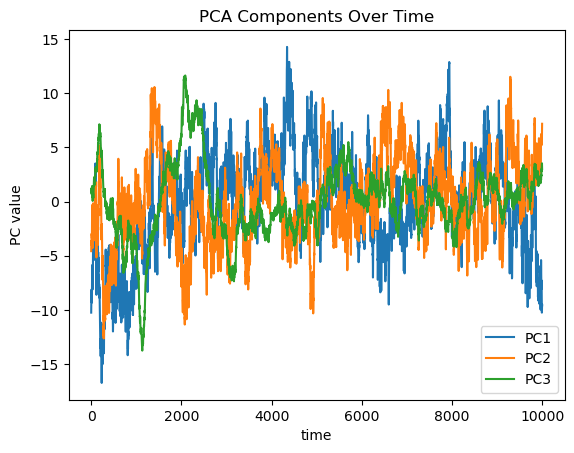

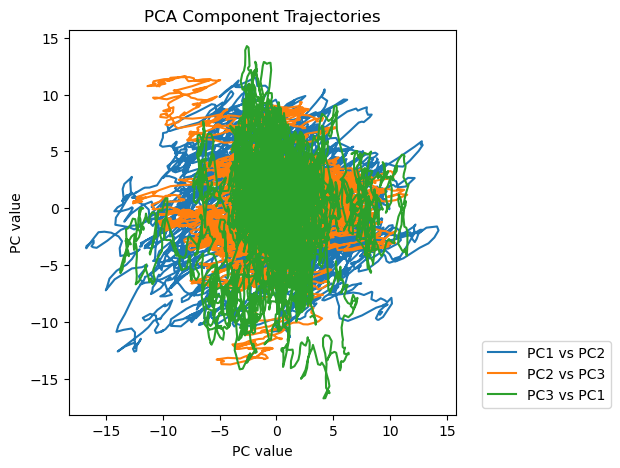

In [14]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.plot(X_pca[:, i], label=f'PC{i+1}')

plt.legend()
plt.xlabel("time")
plt.ylabel("PC value")
plt.title("PCA Components Over Time")
plt.show()

plt.figure(figsize=(5, 5))
for i in range(3):
    j = (i + 1) % 3
    plt.plot(X_pca[:, i], X_pca[:, j],label=f'PC{i+1} vs PC{j+1}')
    

plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left')
plt.xlabel("PC value")
plt.ylabel("PC value")
plt.title("PCA Component Trajectories")
plt.axis('equal')
plt.show()

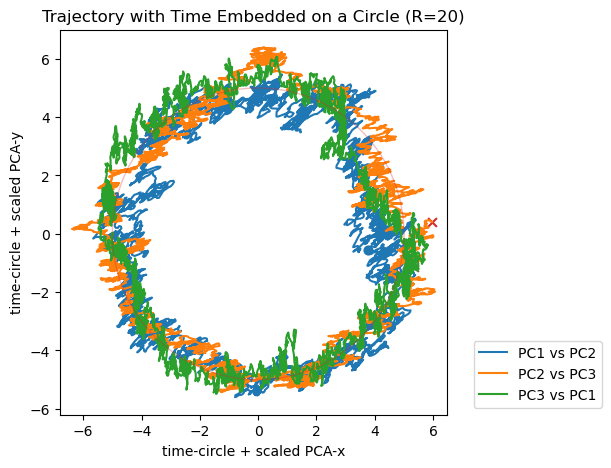

In [15]:
import numpy as np
import matplotlib.pyplot as plt

R = 5
T = X_pca.shape[0]
theta = np.linspace(0, 2*np.pi, T, endpoint=True)

plt.figure(figsize=(5, 5))

for i in range(3):
    j = (i + 1) % 3

    x = X_pca[:, i]
    y = X_pca[:, j]

    p95 = np.percentile(np.sqrt(x**2 + y**2), 95)
    s = (0.25 * R) / (p95 + 1e-9)

    cx = R * np.cos(theta)
    cy = R * np.sin(theta)

    X = cx + s * x
    Y = cy + s * y

    plt.plot(X, Y, label=f'PC{i+1} vs PC{j+1}')

    plt.scatter(X[0],  Y[0],  s=40, marker='o')
    plt.scatter(X[-1], Y[-1], s=40, marker='x')

tt = np.linspace(0, 2*np.pi, 400)
plt.plot(R*np.cos(tt), R*np.sin(tt), linewidth=1, alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left')
plt.axis('equal')
plt.xlabel("time-circle + scaled PCA-x")
plt.ylabel("time-circle + scaled PCA-y")
plt.title("Trajectory with Time Embedded on a Circle (R=20)")
plt.show()

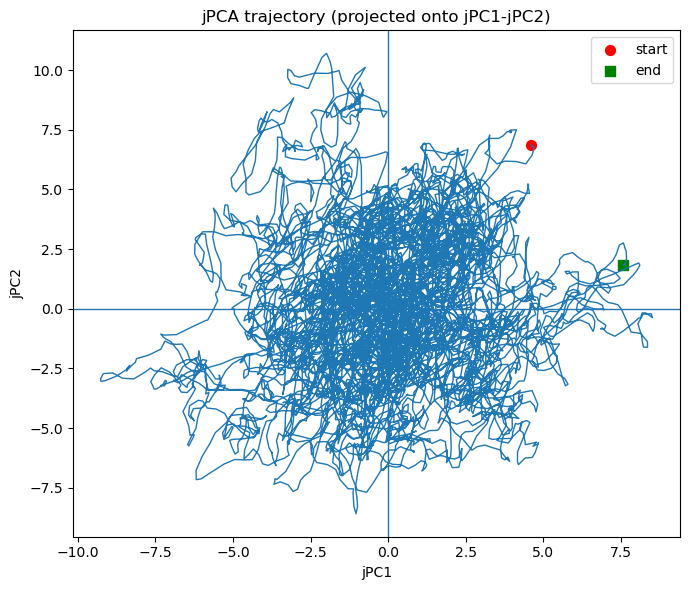

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def finite_diff(X, dt=1.0):
    """Centered finite difference for dX/dt (same length as X)."""
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0]    = (X[1] - X[0]) / dt
    dX[-1]   = (X[-1] - X[-2]) / dt
    return dX

def fit_skew_M(X, dX):
    """
    Fit skew-symmetric M to minimize ||dX - X M^T||_F
    with constraint M^T = -M.
    """
    T, D = X.shape
    assert dX.shape == X.shape

    # Build linear system A m = b for upper-triangular free params of M
    # Parameterize M by entries m_ij for i<j, with:
    # M[i,j]=m_ij, M[j,i]=-m_ij, diag=0.
    pairs = [(i, j) for i in range(D) for j in range(i+1, D)]
    P = len(pairs)

    A = np.zeros((T * D, P), dtype=float)
    b = dX.reshape(-1)

    # For each time t and row k:
    # (X M^T)[t,k] = sum_l X[t,l] * M[k,l]
    # and M[k,l] expressed via m_ij.
    row = 0
    for t in range(T):
        x = X[t]
        for k in range(D):
            for p_idx, (i, j) in enumerate(pairs):
                val = 0.0
                # contribution from M[k,i] and M[k,j] if they exist
                # M[k,l] is:
                #  - if k==i and l==j: +m_ij
                #  - if k==j and l==i: -m_ij
                #  - if k==j and l==i handled similarly, etc.
                if k == i:
                    # term X[t, j] * M[i, j] = X_j * (+m_ij)
                    val += x[j]
                elif k == j:
                    # term X[t, i] * M[j, i] = X_i * (-m_ij)
                    val -= x[i]
                # also need terms where l==k and k==i/j? already covered above (since M[k,l])
                A[row, p_idx] = val
            row += 1

    # Solve least squares
    m_hat, *_ = np.linalg.lstsq(A, b, rcond=None)

    # Reconstruct M
    D = X.shape[1]
    M = np.zeros((D, D), dtype=float)
    for p_idx, (i, j) in enumerate(pairs):
        M[i, j] = m_hat[p_idx]
        M[j, i] = -m_hat[p_idx]
    return M

def jpca(X, dt=1.0, center=True):
    """
    X: (T, D) single trajectory (time-ordered).
    Returns:
      Xc: centered X used for fit
      M: skew-symmetric fitted dynamics
      W: (D,2) jPC plane basis
      Z: (T,2) projected trajectory in jPC plane
    """
    X_use = X.copy()
    if center:
        X_use = X_use - X_use.mean(axis=0, keepdims=True)

    dX = finite_diff(X_use, dt=dt)
    M = fit_skew_M(X_use, dX)

    # For skew-symmetric M, eigenvalues are ± iω. Take the pair with largest |ω|.
    evals, evecs = np.linalg.eig(M)
    omegas = np.abs(np.imag(evals))
    idx = np.argsort(omegas)[::-1]

    # pick the first eigenvector; its conjugate spans the same 2D plane
    v = evecs[:, idx[0]]
    W = np.column_stack([np.real(v), np.imag(v)])  # (D,2)

    # Orthonormalize W
    W, _ = np.linalg.qr(W)

    Z = X_use @ W
    return X_use, M, W, Z

# ====== X_pca jPCA ======
X = X_pca[:, :6]
dt = 1/30

Xc, M, W, Z = jpca(X, dt=dt, center=True)

# ====== jPC1 vs jPC2 ======
plt.figure(figsize=(7, 6))
plt.plot(Z[:, 0], Z[:, 1], lw=1)
plt.scatter(Z[0, 0], Z[0, 1], s=50, color='red', marker='o', label='start')
plt.scatter(Z[-1, 0], Z[-1, 1], s=50, color='green', marker='s', label='end')
plt.axhline(0, lw=1)
plt.axvline(0, lw=1)
plt.xlabel("jPC1")
plt.ylabel("jPC2")
plt.title("jPCA trajectory (projected onto jPC1-jPC2)")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Face Encoding Model

In [61]:
all_window_data = feature.build_all_subject_window_datasets(
    out=data,
    df_face_note=df_face_note,
    window_size_sec=0.5,          # 500 ms
    stride_sec=0.1,               # 100 ms stride
    start_time=0.0,               # 从电影开始切窗
    end_time=478.800,                # 默认到该 sub 的 time_grid 末尾
    remove_baseline_windows=True, # 不把 -10~0 当训练窗
    do_baseline_norm=True,        # 用 baseline 做归一化
    baseline_mode="zscore",       # 可换 center / none / percent_change
    baseline_start=-10.0,
    baseline_end=0.0,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    use_only_valid_face_frames=True,
    valid_face_mode="front_or_face",
    require_all_modalities_nonempty=False,
    verbose=True,
)

[build] subject 41
  -> n_windows = 4784, valid_windows = 4784


In [64]:
all_window_data_filtered = {}

for sub, sub_data in all_window_data.items():
    all_window_data_filtered[sub] = feature.filter_window_dataset(
        sub_data,
        valid_window_only=True,
        min_valid_face_ratio=0.5,
        min_face_frames=5,
        min_non_neutral=None,
        allowed_hard_labels=None,
        require_modalities_nonempty=["firing_rate"],
        verbose=True,
    )

[filter_window_dataset] kept 3801 / 4784 windows


In [66]:
concat_data = feature.concat_subject_window_data(
    all_window_data_filtered,
    subjects=None,
    modality_keys=["firing_rate", "lfp_macro", "lfp_micro", "eye_gaze", "pupil"],
    add_subject_column=True,
    reset_index=True,
    verbose=True,
)

[concat] sub=41, n_windows=3801
[concat_subject_window_data] total windows = 3801


In [79]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


def split_neutral_vs_nonneutral_windows(
    df_window,
    neutral_col="emo_neutral",
    nonneutral_cols=None,
    eps=1e-8
):
    if nonneutral_cols is None:
        nonneutral_cols = ["emo_afraid", "emo_angry", "emo_happy", "emo_surprised"]

    nonneutral_sum = df_window[nonneutral_cols].sum(axis=1)

    neutral_mask = (df_window[neutral_col] > eps) & (nonneutral_sum <= eps)
    nonneutral_mask = (nonneutral_sum > eps)

    return neutral_mask.to_numpy(), nonneutral_mask.to_numpy()


def _stack_equal_length_sequences(seq_list):
    keep_idx_local = []
    X_list = []

    ref_shape = None
    for i, x in enumerate(seq_list):
        if x is None:
            continue

        x = np.asarray(x, dtype=float)

        if x.ndim == 1:
            x = x[:, None]

        if x.size == 0 or np.isnan(x).all():
            continue

        if ref_shape is None:
            ref_shape = x.shape

        if x.shape != ref_shape:
            raise ValueError(
                f"Found unequal window shape: first shape={ref_shape}, current shape={x.shape}. "
                "If windows are not equal length, use padding/truncation first."
            )

        X_list.append(x)
        keep_idx_local.append(i)

    if len(X_list) == 0:
        raise ValueError("No valid sequences found.")

    X = np.stack(X_list, axis=0)   # [N, T, D]
    keep_idx_local = np.asarray(keep_idx_local, dtype=int)
    return X, keep_idx_local


def run_grouped_trajectory_pca_on_concat_data(
    concat_data,
    modality="eye_gaze",
    n_components=3,
    eps=1e-8,
    verbose=True,
):
    df = concat_data["window_df"].copy()
    seq_list = concat_data["sequences"][modality]

    neutral_mask, nonneutral_mask = split_neutral_vs_nonneutral_windows(
        df,
        neutral_col="emo_neutral",
        nonneutral_cols=["emo_afraid", "emo_angry", "emo_happy", "emo_surprised"],
        eps=eps
    )

    neutral_idx = np.where(neutral_mask)[0]
    nonneutral_idx = np.where(nonneutral_mask)[0]

    neutral_seq = [seq_list[i] for i in neutral_idx]
    nonneutral_seq = [seq_list[i] for i in nonneutral_idx]

    X_neutral, keep_neutral_local = _stack_equal_length_sequences(neutral_seq)
    X_nonneutral, keep_nonneutral_local = _stack_equal_length_sequences(nonneutral_seq)

    keep_neutral_idx = neutral_idx[keep_neutral_local]
    keep_nonneutral_idx = nonneutral_idx[keep_nonneutral_local]

    # fit one shared PCA basis
    X_all = np.concatenate([X_neutral, X_nonneutral], axis=0)   # [N_all, T, D]
    N_all, T, D = X_all.shape

    X_all_2d = X_all.reshape(N_all * T, D)

    pca = PCA(n_components=n_components)
    Z_all_2d = pca.fit_transform(X_all_2d)
    Z_all = Z_all_2d.reshape(N_all, T, n_components)

    n_neutral = X_neutral.shape[0]
    Z_neutral = Z_all[:n_neutral]
    Z_nonneutral = Z_all[n_neutral:]

    if verbose:
        print(f"[{modality}] neutral-only windows: {len(keep_neutral_idx)}")
        print(f"[{modality}] non-neutral windows: {len(keep_nonneutral_idx)}")
        print("Shared explained variance ratio:", pca.explained_variance_ratio_)

    return {
        "modality": modality,
        "pca": pca,
        "explained_variance_ratio": pca.explained_variance_ratio_,

        "neutral": {
            "window_idx": keep_neutral_idx,
            "X": X_neutral,              # [N, T, D]
            "Z": Z_neutral,              # [N, T, K]
            "df": df.iloc[keep_neutral_idx].reset_index(drop=True),
        },

        "nonneutral": {
            "window_idx": keep_nonneutral_idx,
            "X": X_nonneutral,           # [N, T, D]
            "Z": Z_nonneutral,           # [N, T, K]
            "df": df.iloc[keep_nonneutral_idx].reset_index(drop=True),
        }
    }

In [80]:
def plot_pc_time_series(
    result,
    pcs=(1, 2, 3),
    with_sem=True,
    figsize=(8, 4),
):
    Z_neu = result["neutral"]["Z"]       # [N, T, K]
    Z_non = result["nonneutral"]["Z"]    # [N, T, K]

    T = Z_neu.shape[1]
    t = np.arange(T)

    fig, axes = plt.subplots(len(pcs), 1, figsize=(figsize[0], figsize[1] * len(pcs)), squeeze=False)

    for row, pc in enumerate(pcs):
        ax = axes[row, 0]
        k = pc - 1

        m_neu = Z_neu[:, :, k].mean(axis=0)
        m_non = Z_non[:, :, k].mean(axis=0)

        ax.plot(t, m_neu, label="neutral")
        ax.plot(t, m_non, label="non-neutral")

        if with_sem:
            se_neu = Z_neu[:, :, k].std(axis=0) / np.sqrt(max(Z_neu.shape[0], 1))
            se_non = Z_non[:, :, k].std(axis=0) / np.sqrt(max(Z_non.shape[0], 1))

            ax.fill_between(t, m_neu - se_neu, m_neu + se_neu, alpha=0.2)
            ax.fill_between(t, m_non - se_non, m_non + se_non, alpha=0.2)

        ax.axhline(0, linestyle="--", alpha=0.5)
        ax.set_title(f"{result['modality']} | PC{pc}")
        ax.set_xlabel("Time within window")
        ax.set_ylabel("Score")
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_grouped_pca(
    result,
    pcx=1,
    pcy=2,
    alpha=0.7,
    s=20,
    equal_axis=True,
    title_suffix=""
):
    """
    result: run_grouped_pca_on_concat_data 输出
    pcx, pcy: 第几个主成分（从1开始）
    """

    Z_neutral = result["neutral"]["Z"]
    Z_nonneutral = result["nonneutral"]["Z"]

    ix = pcx - 1
    iy = pcy - 1

    plt.figure(figsize=(5, 5))

    # neutral
    plt.plot(
        Z_neutral[:, ix],
        Z_neutral[:, iy],
        alpha=alpha,
        label="neutral",
    )

    # non-neutral
    plt.plot(
        Z_nonneutral[:, ix],
        Z_nonneutral[:, iy],
        alpha=alpha,
        label="non-neutral",
    )

    plt.xlabel(f"PC{pcx}")
    plt.ylabel(f"PC{pcy}")
    plt.legend()

    modality = result["modality"]
    plt.title(f"{modality} PCA: neutral vs non-neutral {title_suffix}")

    if equal_axis:
        plt.gca().set_aspect('equal', 'box')

    plt.grid(alpha=0.3)
    plt.show()

[lfp_micro] neutral-only windows: 3301
[lfp_micro] non-neutral windows: 500
Shared explained variance ratio: [0.32332558 0.20257802 0.1251216  0.0764301  0.06280117]


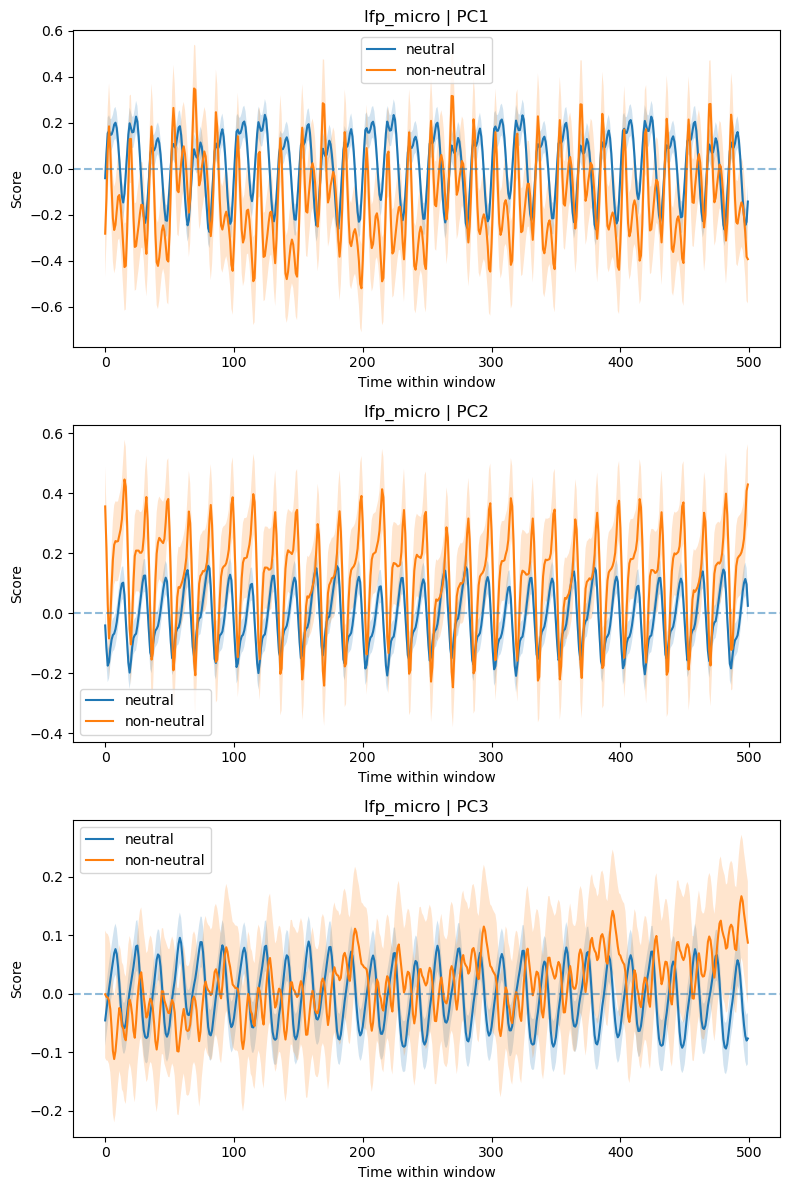

In [84]:
res = run_grouped_trajectory_pca_on_concat_data(concat_data, modality="lfp_micro", n_components=5)

# plot_grouped_pca(res, pcx=1, pcy=2)
# plot_grouped_pca(res, pcx=1, pcy=3)
plot_pc_time_series(res)

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score


def run_decoding_on_res(
    res,
    mode="mean",   # "mean" or "flatten"
    cv=5,
    verbose=True,
):
    """
    输出:
        accuracy + AUC
    """

    Z_neu = res["neutral"]["Z"]       # [N1, T, K]
    Z_non = res["nonneutral"]["Z"]    # [N2, T, K]

    N1 = Z_neu.shape[0]
    N2 = Z_non.shape[0]

    # ===== feature =====
    if mode == "mean":
        X_neu = Z_neu.mean(axis=1)
        X_non = Z_non.mean(axis=1)

    elif mode == "flatten":
        X_neu = Z_neu.reshape(N1, -1)
        X_non = Z_non.reshape(N2, -1)

    else:
        raise ValueError("mode must be 'mean' or 'flatten'")

    X = np.concatenate([X_neu, X_non], axis=0)
    y = np.concatenate([
        np.zeros(N1),
        np.ones(N2)
    ])

    # ===== models =====
    logreg = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced")
    )

    svm = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", probability=True)  # ⚠️ 为了 AUC
    )

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    # ===== evaluation =====
    def evaluate_model(model):
        accs = []
        aucs = []

        for train_idx, test_idx in skf.split(X, y):
            X_tr, X_te = X[train_idx], X[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            model.fit(X_tr, y_tr)

            # accuracy
            y_pred = model.predict(X_te)
            acc = accuracy_score(y_te, y_pred)

            # AUC
            if hasattr(model, "predict_proba"):
                y_score = model.predict_proba(X_te)[:, 1]
            else:
                y_score = model.decision_function(X_te)

            auc = roc_auc_score(y_te, y_score)

            accs.append(acc)
            aucs.append(auc)

        return np.array(accs), np.array(aucs)

    logreg_acc, logreg_auc = evaluate_model(logreg)
    svm_acc, svm_auc = evaluate_model(svm)

    if verbose:
        print("=== Decoding results ===")
        print(f"Mode: {mode}")

        print("\n[Logistic Regression]")
        print(f"Acc: {logreg_acc.mean():.3f} ± {logreg_acc.std():.3f}")
        print(f"AUC: {logreg_auc.mean():.3f} ± {logreg_auc.std():.3f}")

        print("\n[SVM]")
        print(f"Acc: {svm_acc.mean():.3f} ± {svm_acc.std():.3f}")
        print(f"AUC: {svm_auc.mean():.3f} ± {svm_auc.std():.3f}")

    return {
        "logreg": {
            "acc": logreg_acc,
            "auc": logreg_auc,
        },
        "svm": {
            "acc": svm_acc,
            "auc": svm_auc,
        },
        "X": X,
        "y": y
    }

# 推荐先用这个
run_decoding_on_res(res, mode="mean")

# 再试这个（可能更高但不稳定）
run_decoding_on_res(res, mode="flatten")

=== Decoding results ===
Mode: mean
LogReg acc: 0.542 ± 0.011
SVM acc:    0.868 ± 0.000
=== Decoding results ===
Mode: flatten
LogReg acc: 0.797 ± 0.016
SVM acc:    0.804 ± 0.017


{'logreg_scores': array([0.82654402, 0.78684211, 0.79078947, 0.8       , 0.78289474]),
 'svm_scores': array([0.8239159 , 0.80657895, 0.81842105, 0.79736842, 0.775     ]),
 'X': array([[10.23547326,  4.61278408, -0.09859766, ..., -1.10513568,
          3.1945605 ,  1.36263391],
        [ 6.17217704,  1.94822732,  3.05135801, ..., -0.37769278,
         -2.2524628 ,  1.80326023],
        [-2.51614318, -2.31262418,  2.95407896, ...,  0.33740348,
          2.90951822,  1.60207499],
        ...,
        [ 9.16843883,  0.47803602,  1.09127032, ...,  2.86859392,
          0.4765203 , -0.07711238],
        [-0.09252406, -0.27232584,  0.64131348, ...,  3.27216135,
          0.95966473, -0.15295103],
        [-2.82735649,  2.08548502,  0.0247881 , ...,  2.08226243,
         -0.92535685, -2.23798858]], shape=(3801, 2500)),
 'y': array([0., 0., 0., ..., 1., 1., 1.], shape=(3801,))}

In [86]:
import numpy as np
import matplotlib.pyplot as plt


def plot_grouped_pc_heatmap(
    res,
    pcs=None,
    center=True,
    show_diff=True,
    figsize=(14, 4),
    cmap="RdBu_r",
):
    """
    对 grouped trajectory PCA 结果画 PC-time heatmap

    Parameters
    ----------
    res : dict
        run_grouped_trajectory_pca_on_concat_data 的输出
    pcs : list or tuple or None
        要画哪些 PC，1-based index，比如 [1,2,3]
        None 表示画全部 PC
    center : bool
        是否按每个 PC 做时间维去均值，突出动态变化
    show_diff : bool
        是否额外画 nonneutral - neutral 差值图
    figsize : tuple
        单张图尺寸
    cmap : str
        imshow colormap
    """
    Z_neu = np.asarray(res["neutral"]["Z"], dtype=float)       # [N1, T, K]
    Z_non = np.asarray(res["nonneutral"]["Z"], dtype=float)    # [N2, T, K]

    if Z_neu.ndim != 3 or Z_non.ndim != 3:
        raise ValueError("res['neutral']['Z'] and res['nonneutral']['Z'] must be [N, T, K].")

    _, T1, K1 = Z_neu.shape
    _, T2, K2 = Z_non.shape

    if T1 != T2 or K1 != K2:
        raise ValueError(f"neutral Z shape={Z_neu.shape}, nonneutral Z shape={Z_non.shape}, not aligned.")

    T, K = T1, K1

    if pcs is None:
        pc_idx = np.arange(K)
    else:
        pc_idx = np.asarray([p - 1 for p in pcs], dtype=int)
        if np.any(pc_idx < 0) or np.any(pc_idx >= K):
            raise ValueError(f"pcs out of range. available PCs: 1..{K}")

    # [T, K] -> 转成 [K, T] 方便画 heatmap
    M_neu = Z_neu.mean(axis=0).T[pc_idx]    # [K_sel, T]
    M_non = Z_non.mean(axis=0).T[pc_idx]    # [K_sel, T]

    if center:
        M_neu = M_neu - M_neu.mean(axis=1, keepdims=True)
        M_non = M_non - M_non.mean(axis=1, keepdims=True)

    M_diff = M_non - M_neu

    vabs = max(np.max(np.abs(M_neu)), np.max(np.abs(M_non)), 1e-8)
    vabs_diff = max(np.max(np.abs(M_diff)), 1e-8)

    ncols = 3 if show_diff else 2
    fig, axes = plt.subplots(1, ncols, figsize=(figsize[0], figsize[1]), squeeze=False)
    axes = axes[0]

    im0 = axes[0].imshow(
        M_neu,
        aspect="auto",
        origin="lower",
        cmap=cmap,
        vmin=-vabs,
        vmax=vabs,
    )
    axes[0].set_title(f"{res['modality']} | neutral")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("PC")
    axes[0].set_yticks(np.arange(len(pc_idx)))
    axes[0].set_yticklabels([f"PC{p+1}" for p in pc_idx])
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(
        M_non,
        aspect="auto",
        origin="lower",
        cmap=cmap,
        vmin=-vabs,
        vmax=vabs,
    )
    axes[1].set_title(f"{res['modality']} | non-neutral")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("PC")
    axes[1].set_yticks(np.arange(len(pc_idx)))
    axes[1].set_yticklabels([f"PC{p+1}" for p in pc_idx])
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    if show_diff:
        im2 = axes[2].imshow(
            M_diff,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            vmin=-vabs_diff,
            vmax=vabs_diff,
        )
        axes[2].set_title("non-neutral - neutral")
        axes[2].set_xlabel("Time")
        axes[2].set_ylabel("PC")
        axes[2].set_yticks(np.arange(len(pc_idx)))
        axes[2].set_yticklabels([f"PC{p+1}" for p in pc_idx])
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

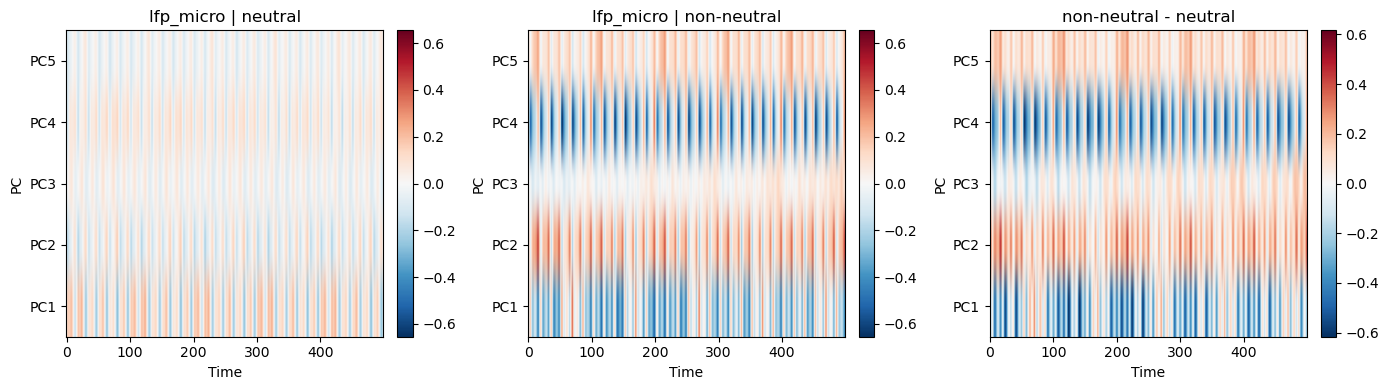

In [87]:
plot_grouped_pc_heatmap(res, center=False)

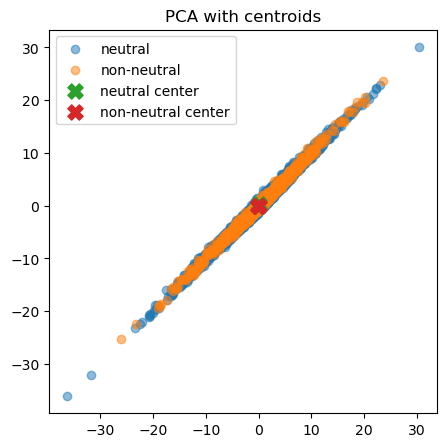

In [83]:
def plot_with_centroid(result):
    Z_n = result["neutral"]["Z"]
    Z_nn = result["nonneutral"]["Z"]

    plt.figure(figsize=(5,5))

    plt.scatter(Z_n[:,0], Z_n[:,1], alpha=0.5, label="neutral")
    plt.scatter(Z_nn[:,0], Z_nn[:,1], alpha=0.5, label="non-neutral")

    # centroid
    c_n = Z_n.mean(axis=0)
    c_nn = Z_nn.mean(axis=0)

    plt.scatter(c_n[0], c_n[1], s=120, marker="X", label="neutral center")
    plt.scatter(c_nn[0], c_nn[1], s=120, marker="X", label="non-neutral center")

    plt.legend()
    plt.title("PCA with centroids")
    plt.gca().set_aspect('equal', 'box')
    plt.show()

plot_with_centroid(res)

In [65]:
sub = list(all_window_data.keys())[0]
df_win = all_window_data[sub]["window_df"]
print(df_win.head())
print(df_win.columns)

   sub  window_start  window_end  n_timepoints  valid_window  \
0   41           0.0         0.5           500          True   
1   41           0.1         0.6           500          True   
2   41           0.2         0.7           500          True   
3   41           0.3         0.8           500          True   
4   41           0.4         0.9           500          True   

   n_face_frames_total  emo_afraid  emo_angry  emo_happy  emo_neutral  \
0                    0         NaN        NaN        NaN          NaN   
1                    0         NaN        NaN        NaN          NaN   
2                    0         NaN        NaN        NaN          NaN   
3                    0         NaN        NaN        NaN          NaN   
4                    0         NaN        NaN        NaN          NaN   

   emo_surprised  p_non_neutral hard_label  valid_face_ratio  \
0            NaN            NaN        NaN               NaN   
1            NaN            NaN        NaN      

In [18]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

def ridge_encoding_cv_single_output(X, y, alpha=10.0, n_splits=5):
    """
    contiguous block CV
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    valid = np.all(np.isfinite(X), axis=1) & np.isfinite(y)
    X = X[valid]
    y = y[valid]

    T = len(y)
    if T < n_splits:
        return {"corr": np.nan, "r2": np.nan, "pred": np.full(T, np.nan)}

    fold_edges = np.linspace(0, T, n_splits + 1).astype(int)
    preds = np.full(T, np.nan, dtype=float)

    for i in range(n_splits):
        te0, te1 = fold_edges[i], fold_edges[i + 1]
        te_idx = np.arange(te0, te1)
        tr_idx = np.setdiff1d(np.arange(T), te_idx)

        xtr, xte = X[tr_idx], X[te_idx]
        ytr = y[tr_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        xtr = x_scaler.fit_transform(xtr)
        xte = x_scaler.transform(xte)
        ytr_z = y_scaler.fit_transform(ytr[:, None]).ravel()

        model = Ridge(alpha=alpha)
        model.fit(xtr, ytr_z)

        yhat_z = model.predict(xte)
        yhat = y_scaler.inverse_transform(yhat_z[:, None]).ravel()
        preds[te_idx] = yhat

    valid_pred = np.isfinite(preds)
    if valid_pred.sum() < 3:
        return {"corr": np.nan, "r2": np.nan, "pred": preds}

    yv = y[valid_pred]
    pv = preds[valid_pred]

    corr = np.corrcoef(yv, pv)[0, 1] if np.std(yv) > 0 and np.std(pv) > 0 else np.nan
    r2 = 1.0 - np.sum((yv - pv) ** 2) / np.sum((yv - np.mean(yv)) ** 2) if np.var(yv) > 0 else np.nan

    return {"corr": corr, "r2": r2, "pred": preds}

def flatten_targets(Y, target_prefix):
    """
    Input
    -----
    Y:
      [T]                  -> 1 target
      [T, C]               -> C targets
      [T, C, B]            -> C*B targets

    Returns
    -------
    Y2d: [T, N_targets]
    target_names: list[str]
    """
    Y = np.asarray(Y, dtype=float)

    if Y.ndim == 1:
        return Y[:, None], [f"{target_prefix}_0"]

    elif Y.ndim == 2:
        n = Y.shape[1]
        names = [f"{target_prefix}_{i}" for i in range(n)]
        return Y, names

    elif Y.ndim == 3:
        T, A, B = Y.shape
        Y2d = Y.reshape(T, A * B)
        names = [f"{target_prefix}_{a}_{b}" for a in range(A) for b in range(B)]
        return Y2d, names

    else:
        raise ValueError(f"Unsupported Y.ndim={Y.ndim}")
    
def run_encoding_for_modality(
    X,
    Y,
    modality_name,
    alpha=10.0,
    n_splits=5,
    max_targets=None,
):
    """
    X: [T, D]
    Y: [T], [T, C], or [T, C, B]
    """
    Y2d, target_names = flatten_targets(Y, modality_name)

    if max_targets is not None:
        Y2d = Y2d[:, :max_targets]
        target_names = target_names[:max_targets]

    rows = []
    for j, target_name in enumerate(target_names):
        y = Y2d[:, j]
        res = ridge_encoding_cv_single_output(X, y, alpha=alpha, n_splits=n_splits)

        rows.append({
            "modality": modality_name,
            "target": target_name,
            "corr": res["corr"],
            "r2": res["r2"],
        })

    return pd.DataFrame(rows)

def run_face_encoding_all_modalities(
    df_face_note,
    sub_dict,
    face_feature_sets,
    method_map=None,
    lags_sec=(-0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.5),
    alpha=10.0,
    n_splits=5,
    max_targets_per_modality=None,
):
    t_grid = np.asarray(sub_dict["time_grid"], dtype=float)
    dt = float(np.median(np.diff(t_grid)))
    lags = np.round(np.asarray(lags_sec) / dt).astype(int)

    all_face_cols = sorted(set(sum(face_feature_sets.values(), [])))

    df_face_grid = slicer.resample_face_df_to_timegrid(
        df_face_note,
        t_grid,
        all_face_cols,
        method_map=method_map,
    )

    results = []

    for model_name, cols in face_feature_sets.items():
        X = df_face_grid[cols].astype(float).to_numpy()
        X_lag = feature.make_lagged_matrix(X, lags)

        modality_specs = {
            "firing_rate": sub_dict.get("firing_rate", None),
            "lfp_macro": sub_dict.get("lfp_macro", None),
            "lfp_micro": sub_dict.get("lfp_micro", None),
            "lfp_bandpower": sub_dict.get("lfp_bandpower", None),
            "pupil": sub_dict.get("pupil", None),
            "eye_gaze": sub_dict.get("eye_gaze", None),
        }

        for modality_name, Y in modality_specs.items():
            if Y is None:
                continue

            try:
                df_res = run_encoding_for_modality(
                    X=X_lag,
                    Y=Y,
                    modality_name=modality_name,
                    alpha=alpha,
                    n_splits=n_splits,
                    max_targets=max_targets_per_modality,
                )
                df_res["model_name"] = model_name
                results.append(df_res)
            except Exception as e:
                results.append(pd.DataFrame([{
                    "modality": modality_name,
                    "target": None,
                    "corr": np.nan,
                    "r2": np.nan,
                    "model_name": model_name,
                    "error": repr(e),
                }]))

    if len(results) == 0:
        return pd.DataFrame()

    return pd.concat(results, axis=0, ignore_index=True)

In [19]:
face_feature_sets = {
    "quantity": ["n_faces", "total_face_area", "max_face_area"],
    "identity": ["Jacky_present"],
    "pose_emotion": [
        "any_front_face",
        "emo_afraid", "emo_angry", "emo_happy",
        "emo_neutral", "emo_surprised"
    ],
    "all_face": [
        "n_faces", "total_face_area", "max_face_area",
        "Jacky_present", "any_front_face",
        "emo_afraid", "emo_angry", "emo_happy",
        "emo_neutral", "emo_surprised"
    ]
}

method_map = {
    "n_faces": "nearest",
    "total_face_area": "linear",
    "max_face_area": "linear",
    "Jacky_present": "nearest",
    "any_front_face": "nearest",
    "emo_afraid": "nearest",
    "emo_angry": "nearest",
    "emo_happy": "nearest",
    "emo_neutral": "nearest",
    "emo_surprised": "nearest",
}

sub = list(data.keys())[0]

df_result = run_face_encoding_all_modalities(
    df_face_note=df_face_note,
    sub_dict=data[sub],
    face_feature_sets=face_feature_sets,
    method_map=method_map,
    lags_sec=(-0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.5),
    alpha=10.0,
    n_splits=5,
    max_targets_per_modality=20,
)

print(df_result)

          modality         target      corr        r2 model_name  \
0      firing_rate  firing_rate_0 -0.001604 -0.000094   quantity   
1      firing_rate  firing_rate_1  0.000022 -0.000036   quantity   
2      firing_rate  firing_rate_2 -0.000203 -0.000063   quantity   
3      firing_rate  firing_rate_3  0.001573 -0.000032   quantity   
4      firing_rate  firing_rate_4  0.002523 -0.000035   quantity   
..             ...            ...       ...       ...        ...   
199      lfp_micro   lfp_micro_19  0.034573 -0.052330   all_face   
200  lfp_bandpower           None       NaN       NaN   all_face   
201          pupil        pupil_0  0.148087 -0.014405   all_face   
202       eye_gaze     eye_gaze_0 -0.063445 -0.095297   all_face   
203       eye_gaze     eye_gaze_1 -0.106102 -0.146655   all_face   

                                                 error  
0                                                  NaN  
1                                                  NaN  
2           

In [20]:
df_result.groupby(["modality", "model_name"])[["corr", "r2"]].mean()

corr        r2
modality      model_name                      
eye_gaze      all_face     -0.084774 -0.120976
              identity     -0.117075 -0.038549
              pose_emotion -0.099240 -0.100063
              quantity     -0.056059 -0.029604
firing_rate   all_face      0.000251 -0.000532
              identity     -0.000398 -0.000037
              pose_emotion  0.000279 -0.000428
              quantity     -0.000483 -0.000067
lfp_bandpower all_face           NaN       NaN
              identity           NaN       NaN
              pose_emotion       NaN       NaN
              quantity           NaN       NaN
lfp_macro     all_face      0.001814 -0.101092
              identity      0.003659 -0.000846
              pose_emotion -0.001217 -0.096995
              quantity     -0.001450 -0.002747
lfp_micro     all_face      0.030872 -0.075891
              identity     -0.014368 -0.001532
              pose_emotion  0.011048 -0.063668
              quantity      0.057969 -0.000214
pupil         all_face      0.148087 -0.014405
              identity      0.107573  0.003979
              pose_emotion  0.129494 -0.016544
              quantity      0.164033  0.021730


===== firing_rate =====


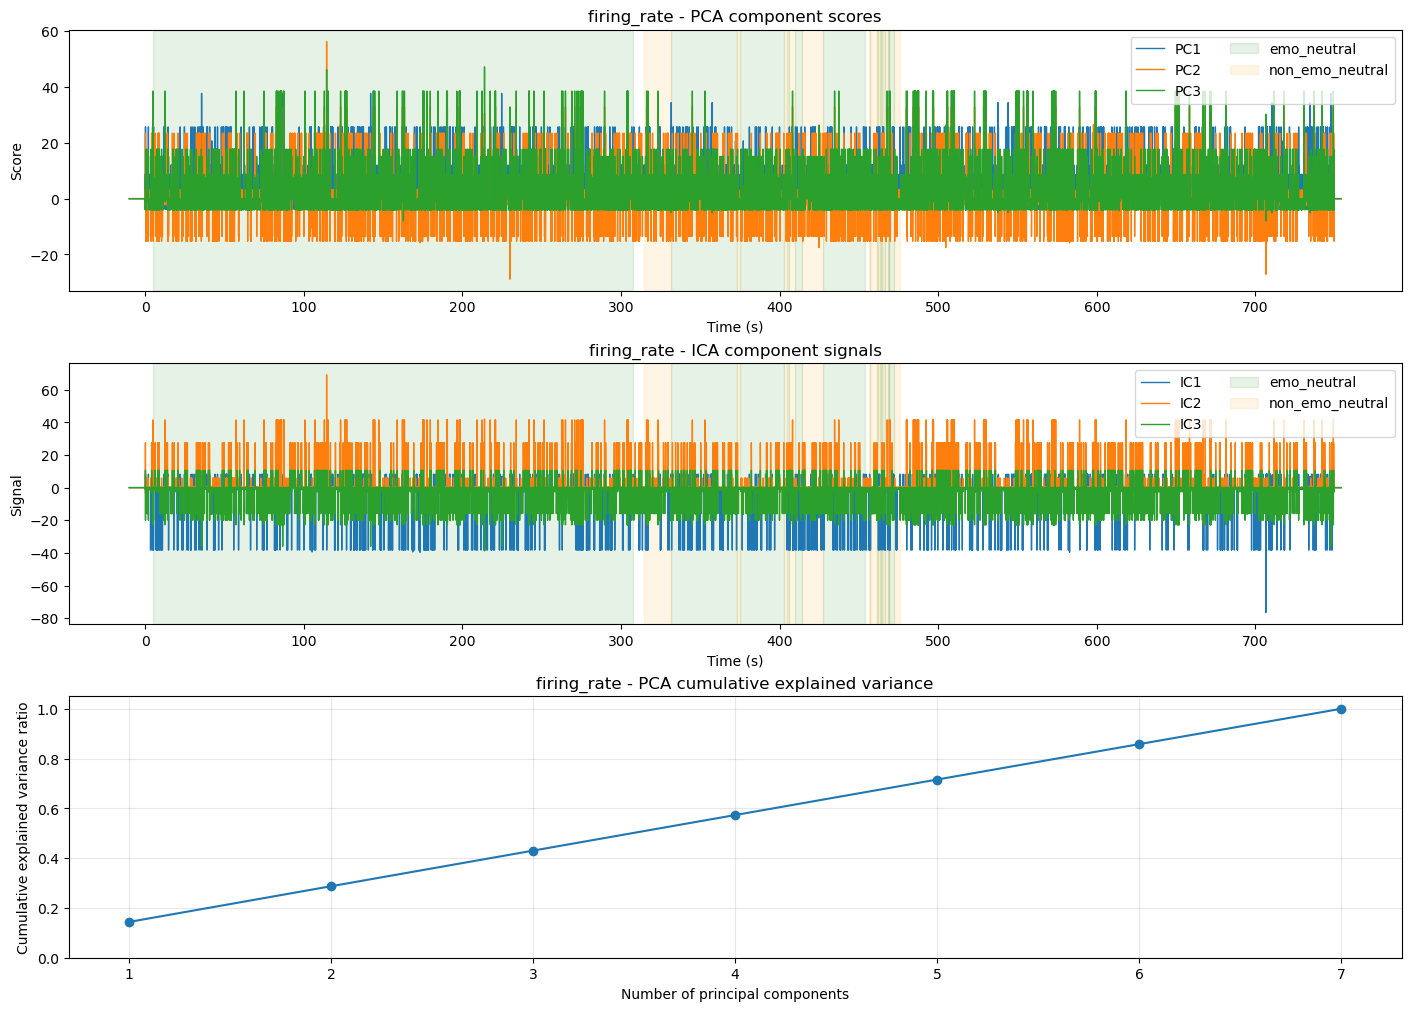


===== lfp_macro =====


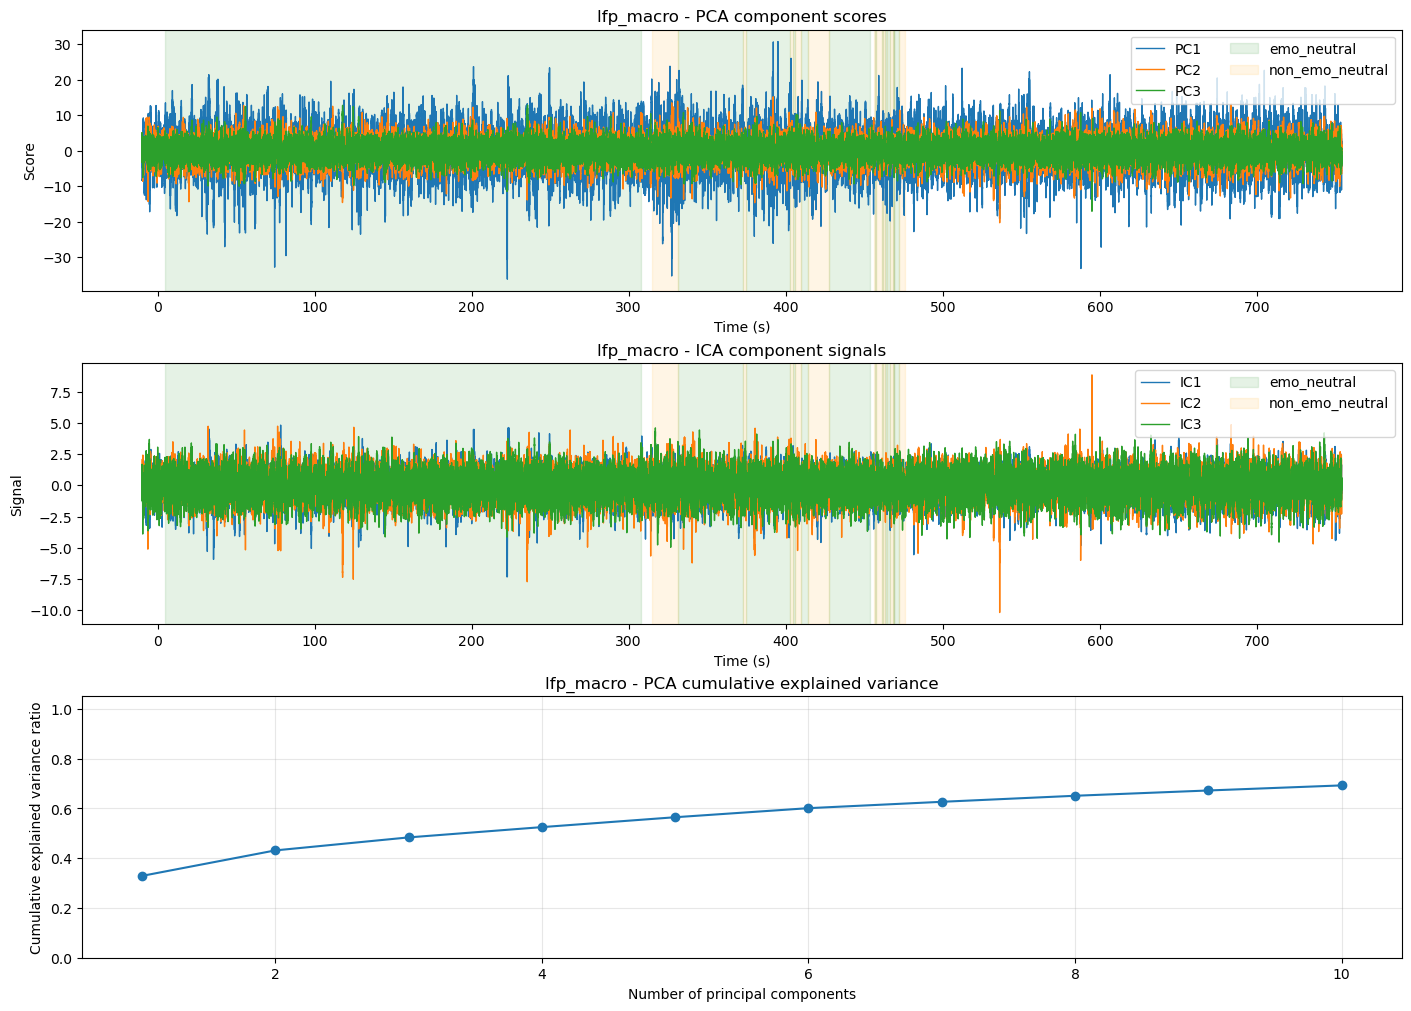


===== lfp_micro =====


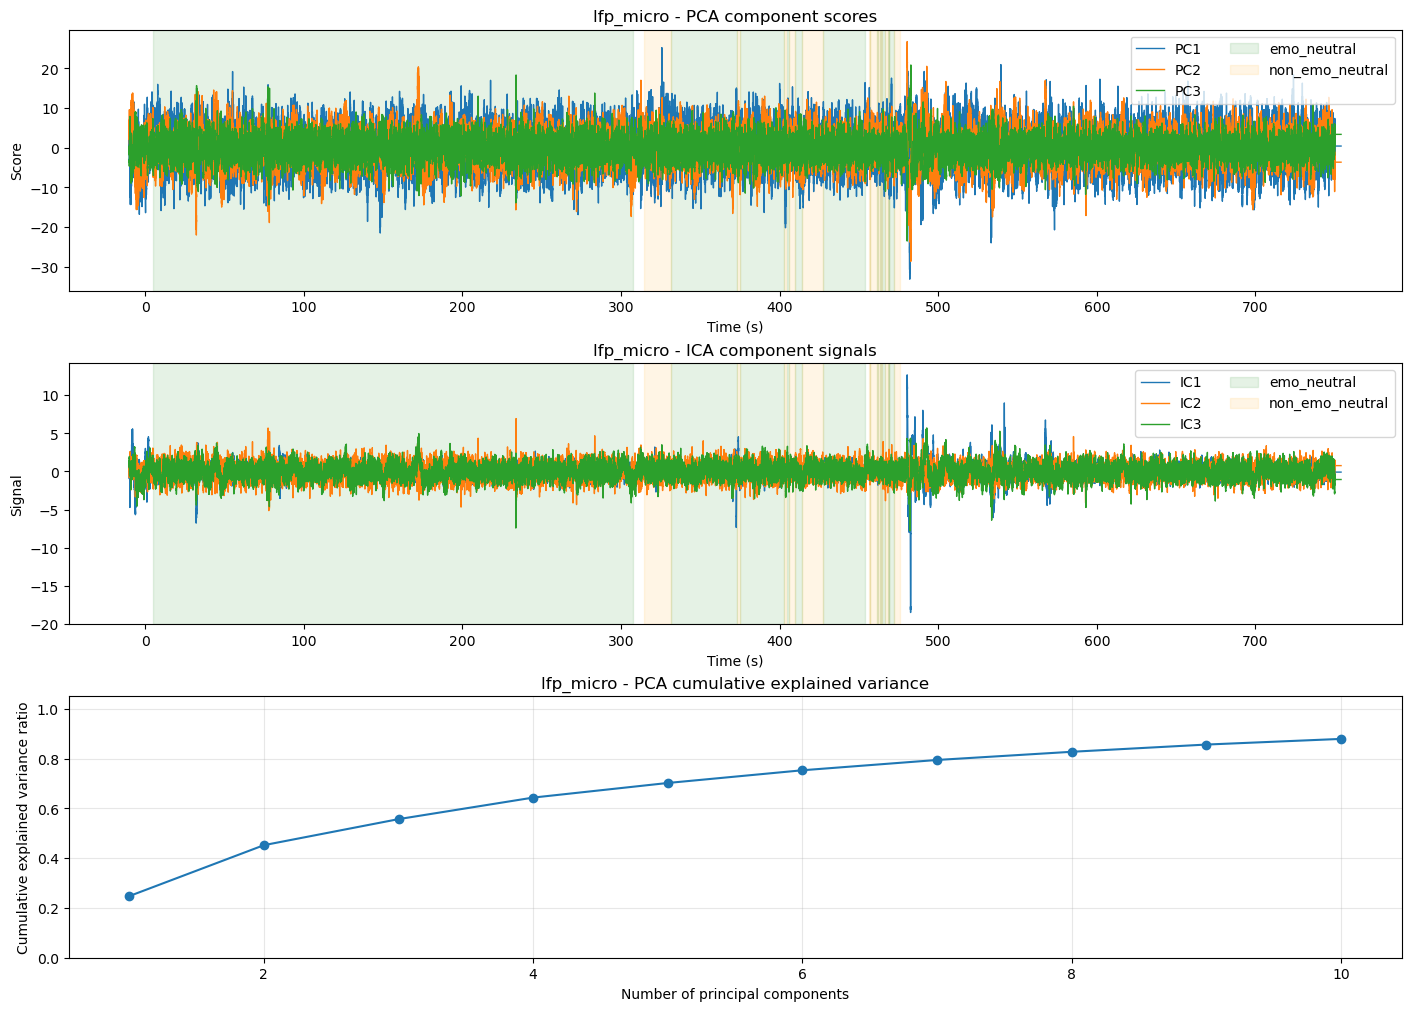


===== eye_gaze =====


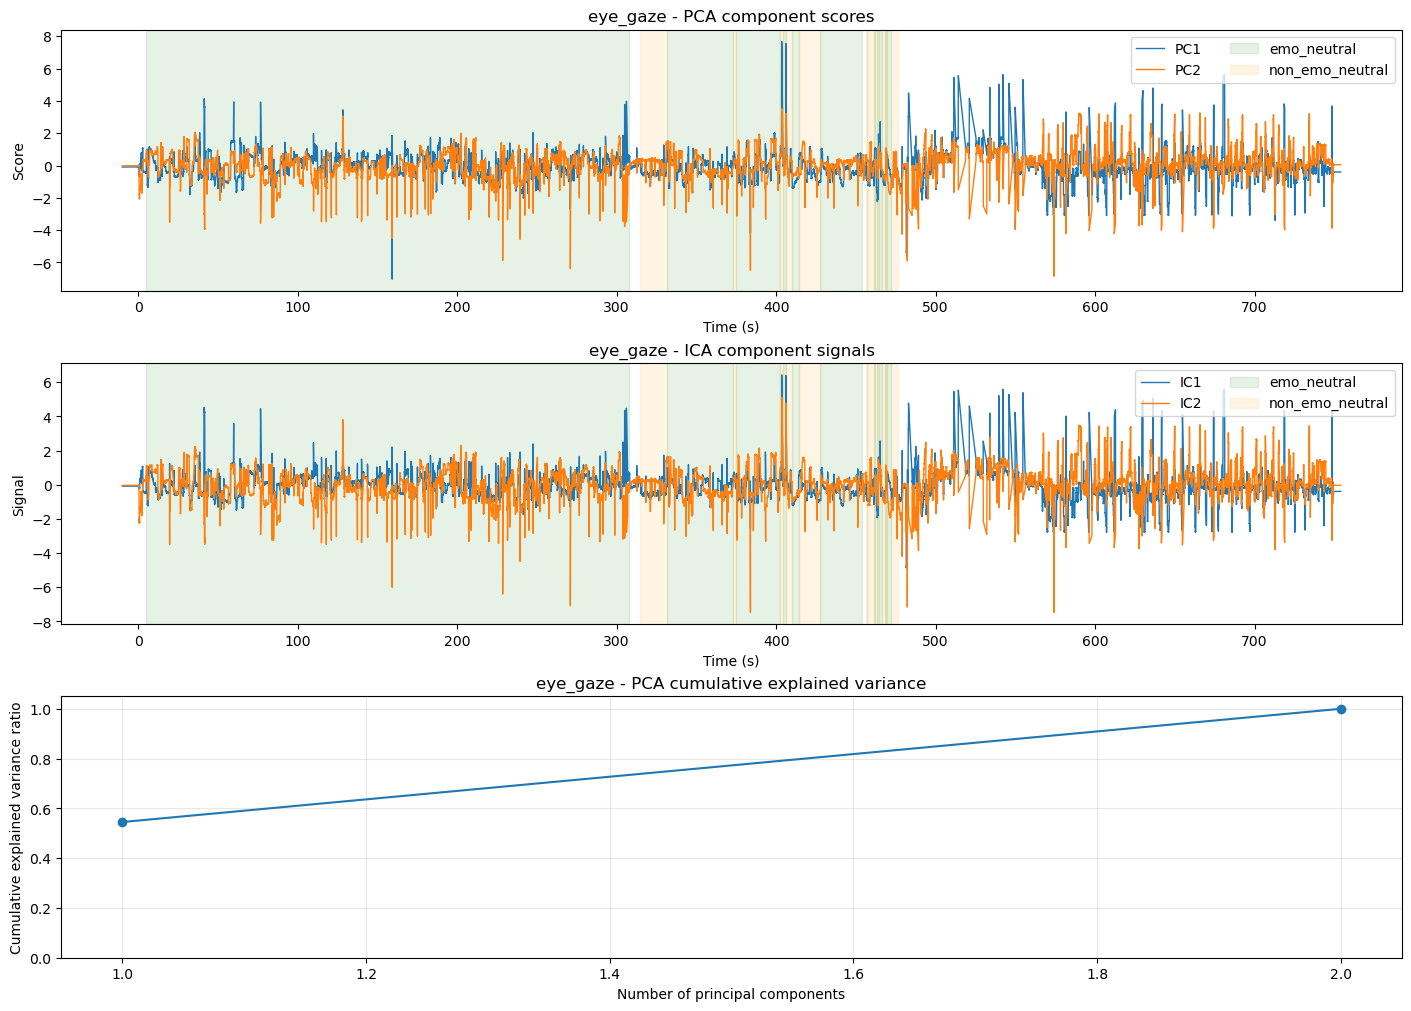


===== pupil =====
[skip] pupil: effective feature dim < 2 after cleaning


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler


# =========================
# 1. 基础工具
# =========================
def _ensure_2d_time_by_feature(x, target_len=None, name="modality"):
    """
    尽量把输入整理成 [T, D] 形式。
    支持:
      - 1D: [T] -> [T, 1]
      - 2D: [T, D] or [D, T]
      - 3D+: 若某一维等于 target_len，则把那一维移到前面并 flatten 其余维
    """
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        return x[:, None]

    if x.ndim == 2:
        # 如果给了 target_len，就优先让第一维=T
        if target_len is not None:
            if x.shape[0] == target_len:
                return x
            elif x.shape[1] == target_len:
                return x.T
        # 否则默认第一维是时间
        return x

    # ndim >= 3
    if target_len is not None:
        axes = list(range(x.ndim))
        time_axis = None
        for ax, s in enumerate(x.shape):
            if s == target_len:
                time_axis = ax
                break
        if time_axis is not None:
            x = np.moveaxis(x, time_axis, 0)   # [T, ...]
            T = x.shape[0]
            return x.reshape(T, -1)

    # fallback: 默认第一维是时间
    T = x.shape[0]
    return x.reshape(T, -1)


def _fill_nan_2d(X):
    """
    对 [T, D] 矩阵按列填 NaN:
    - 先用列均值填
    - 若整列全 NaN，则填 0
    """
    X = np.asarray(X, dtype=np.float64).copy()
    col_mean = np.nanmean(X, axis=0)

    # 整列全nan -> nanmean会是nan，这里置0
    col_mean = np.where(np.isnan(col_mean), 0.0, col_mean)

    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_mean, inds[1])
    return X


def get_time_axis_for_modality(sub_data, modality):
    """
    给每个模态找一个时间轴（秒）。
    优先：
      1) resampled continuous modality -> time_grid
      2) 若长度和 movieframe_time_sec 一致 -> movieframe_time_sec
      3) 若存在 raw time -> time_raw[...]
    """
    arr = sub_data.get(modality, None)
    if arr is None:
        return None

    time_grid = np.asarray(sub_data.get("time_grid", []), dtype=np.float64)
    movie_t = np.asarray(sub_data.get("movieframe_time_sec", []), dtype=np.float64)

    # raw time
    time_raw_dict = sub_data.get("time_raw", {})
    raw_key_map = {
        "lfp_macro": "lfp_macro",
        "lfp_micro": "lfp_micro",
        "eye_gaze": "eye",
        "pupil": "eye",
    }
    raw_t = None
    if modality in raw_key_map and raw_key_map[modality] in time_raw_dict:
        raw_t = time_raw_dict[raw_key_map[modality]]
        if raw_t is not None:
            raw_t = np.asarray(raw_t, dtype=np.float64)

    # 先猜长度
    candidate = _ensure_2d_time_by_feature(arr, target_len=len(time_grid), name=modality)
    if candidate is not None and len(time_grid) > 0 and candidate.shape[0] == len(time_grid):
        return time_grid

    if len(movie_t) > 0:
        candidate = _ensure_2d_time_by_feature(arr, target_len=len(movie_t), name=modality)
        if candidate is not None and candidate.shape[0] == len(movie_t):
            return movie_t

    if raw_t is not None:
        candidate = _ensure_2d_time_by_feature(arr, target_len=len(raw_t), name=modality)
        if candidate is not None and candidate.shape[0] == len(raw_t):
            return raw_t

    # fallback
    X = _ensure_2d_time_by_feature(arr, target_len=None, name=modality)
    if X is None:
        return None
    return np.arange(X.shape[0], dtype=np.float64)


# =========================
# 2. annotation 区间提取
# =========================
def extract_boolean_spans(time_arr, flag_arr):
    """
    根据 time_arr 和布尔 flag_arr 提取连续区间 [(start, end), ...]
    """
    time_arr = np.asarray(time_arr, dtype=np.float64)
    flag_arr = np.asarray(flag_arr).astype(bool)

    assert len(time_arr) == len(flag_arr)

    spans = []
    if len(time_arr) == 0:
        return spans

    in_span = False
    start_t = None

    for i in range(len(flag_arr)):
        if flag_arr[i] and not in_span:
            in_span = True
            start_t = time_arr[i]
        elif (not flag_arr[i]) and in_span:
            end_t = time_arr[i - 1]
            spans.append((start_t, end_t))
            in_span = False
            start_t = None

    if in_span:
        spans.append((start_t, time_arr[-1]))

    return spans


def get_emotion_spans(df_face):
    """
    从 face annotation dataframe 中提取
      - neutral spans
      - non-neutral spans
    需要列:
      - movie_time
      - emo_neutral
    """
    df = df_face.copy().sort_values("movie_time").reset_index(drop=True)

    if "emo_neutral" not in df.columns:
        raise ValueError("df_face 里没有 'emo_neutral' 列")
    if "movie_time" not in df.columns:
        raise ValueError("df_face 里没有 'movie_time' 列")

    movie_time = df["movie_time"].to_numpy(dtype=np.float64)
    neutral_flag = df["emo_neutral"].astype(bool).to_numpy()
    nonneutral_flag = ~neutral_flag

    neutral_spans = extract_boolean_spans(movie_time, neutral_flag)
    nonneutral_spans = extract_boolean_spans(movie_time, nonneutral_flag)

    return neutral_spans, nonneutral_spans


def add_emotion_spans(ax, neutral_spans, nonneutral_spans,
                      neutral_alpha=0.10, nonneutral_alpha=0.10):
    """
    在时间图上标注 neutral / non-neutral 区间
    """
    # neutral: 浅绿色
    for i, (s, e) in enumerate(neutral_spans):
        ax.axvspan(
            s, e,
            alpha=neutral_alpha,
            color="green",
            label="emo_neutral" if i == 0 else None
        )

    # non-neutral: 浅橙色
    for i, (s, e) in enumerate(nonneutral_spans):
        ax.axvspan(
            s, e,
            alpha=nonneutral_alpha,
            color="orange",
            label="non_emo_neutral" if i == 0 else None
        )


# =========================
# 3. 单模态 PCA/ICA + 作图
# =========================
def analyze_one_modality(
    sub_data,
    modality,
    df_face,
    n_pca=10,
    n_ica=5,
    standardize=True,
    plot_n_comp=3,
    figsize=(14, 10)
):
    """
    对一个模态:
      - 整理成 [T, D]
      - PCA
      - ICA
      - 画:
          1) PCA前几个score的时间图
          2) ICA前几个source的时间图
          3) PCA累计解释方差图
    """
    arr = sub_data.get(modality, None)
    if arr is None:
        print(f"[skip] {modality}: not found in sub_data")
        return None

    t = get_time_axis_for_modality(sub_data, modality)
    if t is None:
        print(f"[skip] {modality}: no valid time axis")
        return None

    X = _ensure_2d_time_by_feature(arr, target_len=len(t), name=modality)
    if X is None:
        print(f"[skip] {modality}: cannot convert to 2D")
        return None

    # 再检查一下长度是否匹配
    if X.shape[0] != len(t):
        print(f"[skip] {modality}: time length mismatch, X={X.shape}, len(t)={len(t)}")
        return None

    # 去掉全常数列/全nan列前先填nan
    X = _fill_nan_2d(X)

    # 去掉方差为0的列
    col_std = np.std(X, axis=0)
    keep = col_std > 1e-12
    X = X[:, keep]

    if X.shape[1] < 2:
        print(f"[skip] {modality}: effective feature dim < 2 after cleaning")
        return None

    # 标准化
    if standardize:
        scaler = StandardScaler()
        Xz = scaler.fit_transform(X)
    else:
        Xz = X.copy()

    # PCA
    pca_k = min(n_pca, Xz.shape[0], Xz.shape[1])
    pca = PCA(n_components=pca_k, random_state=0)
    X_pca = pca.fit_transform(Xz)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    # ICA
    ica_k = min(n_ica, Xz.shape[0], Xz.shape[1])
    ica = FastICA(n_components=ica_k, random_state=0, max_iter=2000, tol=1e-4)
    try:
        X_ica = ica.fit_transform(Xz)
        ica_ok = True
    except Exception as e:
        print(f"[warn] {modality}: ICA failed -> {e}")
        X_ica = None
        ica_ok = False

    # emotion spans
    neutral_spans, nonneutral_spans = get_emotion_spans(df_face)

    # ========== Plot ==========
    fig, axes = plt.subplots(3, 1, figsize=figsize, constrained_layout=True)

    # 1) PCA score time series
    ax = axes[0]
    n_show_pca = min(plot_n_comp, X_pca.shape[1])
    for i in range(n_show_pca):
        ax.plot(t, X_pca[:, i], label=f"PC{i+1}", linewidth=1.0)
    add_emotion_spans(ax, neutral_spans, nonneutral_spans)
    ax.set_title(f"{modality} - PCA component scores")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Score")
    ax.legend(loc="upper right", ncol=2)

    # 2) ICA source time series
    ax = axes[1]
    if ica_ok and X_ica is not None:
        n_show_ica = min(plot_n_comp, X_ica.shape[1])
        for i in range(n_show_ica):
            ax.plot(t, X_ica[:, i], label=f"IC{i+1}", linewidth=1.0)
        add_emotion_spans(ax, neutral_spans, nonneutral_spans)
        ax.set_title(f"{modality} - ICA component signals")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.legend(loc="upper right", ncol=2)
    else:
        ax.text(0.5, 0.5, f"ICA failed for {modality}", ha="center", va="center", fontsize=12)
        ax.set_title(f"{modality} - ICA component signals")
        ax.set_axis_off()

    # 3) Cumulative explained variance
    ax = axes[2]
    ax.plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o")
    ax.set_title(f"{modality} - PCA cumulative explained variance")
    ax.set_xlabel("Number of principal components")
    ax.set_ylabel("Cumulative explained variance ratio")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

    plt.show()

    return {
        "modality": modality,
        "time": t,
        "X": X,
        "pca_model": pca,
        "pca_scores": X_pca,
        "cum_explained_variance": cumvar,
        "ica_model": ica if ica_ok else None,
        "ica_sources": X_ica,
        "neutral_spans": neutral_spans,
        "nonneutral_spans": nonneutral_spans,
    }


# =========================
# 4. 批量分析多个模态
# =========================
def analyze_modalities(
    sub_data,
    df_face,
    modalities=None,
    n_pca=10,
    n_ica=5,
    standardize=True,
    plot_n_comp=3,
):
    if modalities is None:
        modalities = [
            "firing_rate",
            "lfp_macro",
            "lfp_micro",
            "lfp_bandpower",
            "eye_gaze",
            "pupil",
        ]

    results = {}
    for modality in modalities:
        print(f"\n===== {modality} =====")
        res = analyze_one_modality(
            sub_data=sub_data,
            modality=modality,
            df_face=df_face,
            n_pca=n_pca,
            n_ica=n_ica,
            standardize=standardize,
            plot_n_comp=plot_n_comp,
        )
        results[modality] = res

    return results
results = analyze_modalities(
    sub_data=data[sub],
    df_face=df_face_note,
    modalities=[
        "firing_rate",
        "lfp_macro",
        "lfp_micro",
        "eye_gaze",
        "pupil",
    ],
    n_pca=10,
    n_ica=5,
    standardize=True,
    plot_n_comp=3,
)

In [22]:
from numpy.linalg import lstsq, eig
from scipy.signal import detrend

def compute_jpca(X, dt):
    """
    X: [T, D]
    dt: scalar
    """
    X = np.asarray(X, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape={X.shape}")
    if X.shape[0] < 3:
        raise ValueError(f"Need at least 3 time points, got shape={X.shape}")
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError(f"dt must be positive finite, got dt={dt}")

    # 对齐成:
    # X_prev[t] 对应 dX[t] = (X[t+1]-X[t]) / dt
    X_prev = X[:-1]                    # [T-1, D]
    dX = np.diff(X, axis=0) / dt       # [T-1, D]

    # fit: dX = X_prev @ M
    M, _, _, _ = lstsq(X_prev, dX, rcond=None)   # M shape [D, D]

    # 旋转部分
    M_skew = 0.5 * (M - M.T)

    eigvals, eigvecs = eig(M_skew)
    return M, M_skew, eigvals, eigvecs

def project_to_jpca_plane(X, eigvecs, eigvals):
    """
    取虚部最大的那一对特征向量，构造2D jPCA plane
    """
    imag_strength = np.abs(np.imag(eigvals))
    idx = np.argsort(imag_strength)[-2:]

    W = np.real(eigvecs[:, idx])   # [D, 2]
    X_jpca = X @ W                 # [T, 2]
    return X_jpca, W, idx


def plot_jpca_trajectory(X_jpca, modality):
    plt.figure(figsize=(5, 5))
    plt.plot(X_jpca[:, 0], X_jpca[:, 1], linewidth=1)
    plt.scatter(X_jpca[0, 0], X_jpca[0, 1], label="start")
    plt.scatter(X_jpca[-1, 0], X_jpca[-1, 1], label="end")
    plt.xlabel("jPC1")
    plt.ylabel("jPC2")
    plt.title(f"{modality} jPCA plane")
    plt.legend()
    plt.axis("equal")
    plt.show()


def run_jpca_on_result(res, n_input_pc=6):
    X = np.asarray(res["pca_scores"], dtype=np.float64)
    X = detrend(X, axis=0)
    t = np.asarray(res["time"], dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"pca_scores must be 2D, got {X.shape}")
    if len(t) != X.shape[0]:
        raise ValueError(f"time length {len(t)} != X rows {X.shape[0]}")
    if len(t) < 3:
        raise ValueError(f"Need at least 3 time points, got {len(t)}")

    # 去掉非有限时间差
    dt_all = np.diff(t)
    dt_all = dt_all[np.isfinite(dt_all) & (dt_all > 0)]
    if len(dt_all) == 0:
        raise ValueError("No valid positive dt found in time axis")
    dt = np.median(dt_all)

    # 限制输入维数
    k = min(n_input_pc, X.shape[1])
    X = X[:, :k]

    # 去掉含nan的行
    good = np.isfinite(X).all(axis=1) & np.isfinite(t)
    X = X[good]
    t = t[good]

    if X.shape[0] < 3:
        raise ValueError(f"Not enough valid rows after cleaning: {X.shape}")

    M, M_skew, eigvals, eigvecs = compute_jpca(X, dt)
    X_jpca, W, idx = project_to_jpca_plane(X, eigvecs, eigvals)

    plot_jpca_trajectory(X_jpca, res["modality"])

    print(f"{res['modality']} | input_dim={k}, T={X.shape[0]}, dt={dt:.6f}")
    print("eigenvalues:", eigvals)
    print("imag parts:", np.imag(eigvals))

    return {
        "X_jpca": X_jpca,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "W": W,
        "idx": idx,
        "M": M,
        "M_skew": M_skew,
        "dt": dt,
    }


==== firing_rate ====


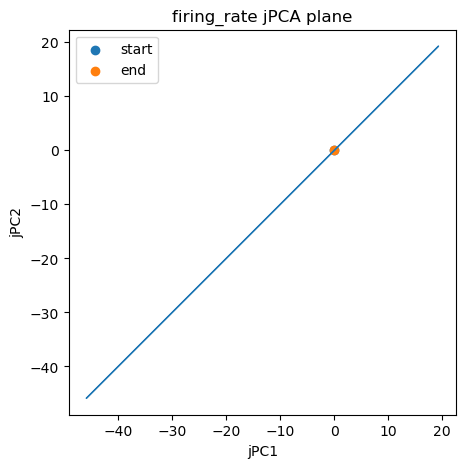

firing_rate | input_dim=6, T=763964, dt=0.001000
eigenvalues: [ 4.40086804e-17+2.83914177j  4.40086804e-17-2.83914177j
 -9.62957421e-17+0.51151306j -9.62957421e-17-0.51151306j
  2.04237390e-17+1.31989734j  2.04237390e-17-1.31989734j]
imag parts: [ 2.83914177 -2.83914177  0.51151306 -0.51151306  1.31989734 -1.31989734]

==== lfp_macro ====


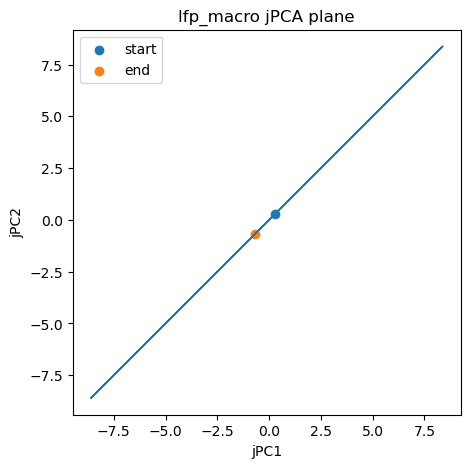

lfp_macro | input_dim=6, T=763964, dt=0.001000
eigenvalues: [-2.11696297e-16+8.08011304j -2.11696297e-16-8.08011304j
 -8.88178420e-16+5.30883137j -8.88178420e-16-5.30883137j
  1.96201344e-16+0.67839599j  1.96201344e-16-0.67839599j]
imag parts: [ 8.08011304 -8.08011304  5.30883137 -5.30883137  0.67839599 -0.67839599]

==== lfp_micro ====


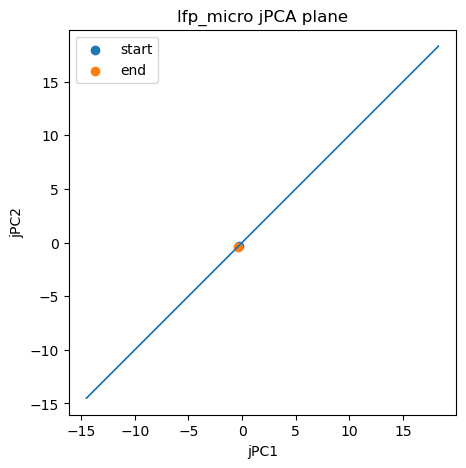

lfp_micro | input_dim=6, T=763964, dt=0.001000
eigenvalues: [ 1.79040669e-16+4.85629942j  1.79040669e-16-4.85629942j
 -7.54271327e-17+1.51554634j -7.54271327e-17-1.51554634j
  6.60840152e-20+0.24945952j  6.60840152e-20-0.24945952j]
imag parts: [ 4.85629942 -4.85629942  1.51554634 -1.51554634  0.24945952 -0.24945952]

==== eye_gaze ====


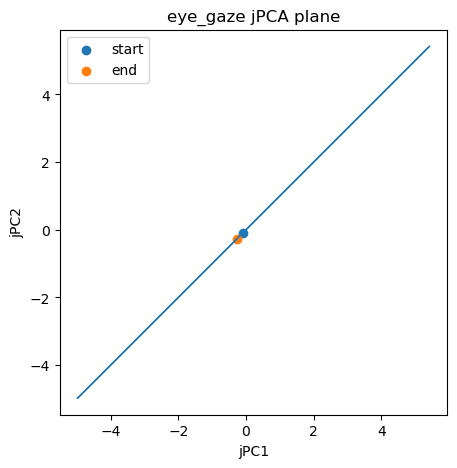

eye_gaze | input_dim=2, T=763964, dt=0.001000
eigenvalues: [0.+0.0241269j 0.-0.0241269j]
imag parts: [ 0.0241269 -0.0241269]


In [23]:
jpca_results = {}

for modality, res in results.items():
    if res is None:
        continue

    print("\n====", modality, "====")
    try:
        jpca_results[modality] = run_jpca_on_result(res, n_input_pc=6)
    except Exception as e:
        print(f"[skip] {modality}: {e}")